<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [77]:
#wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

#### Install the required libraries and import them


In [78]:
#pip install pandas

In [79]:
#pip install matplotlib

In [80]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#### Connect to the SQLite database


In [81]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [82]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


**Demo 2: List all tables**


In [83]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [84]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


Data loaded: 32733 valid values
Range: $0 to $9,912,000


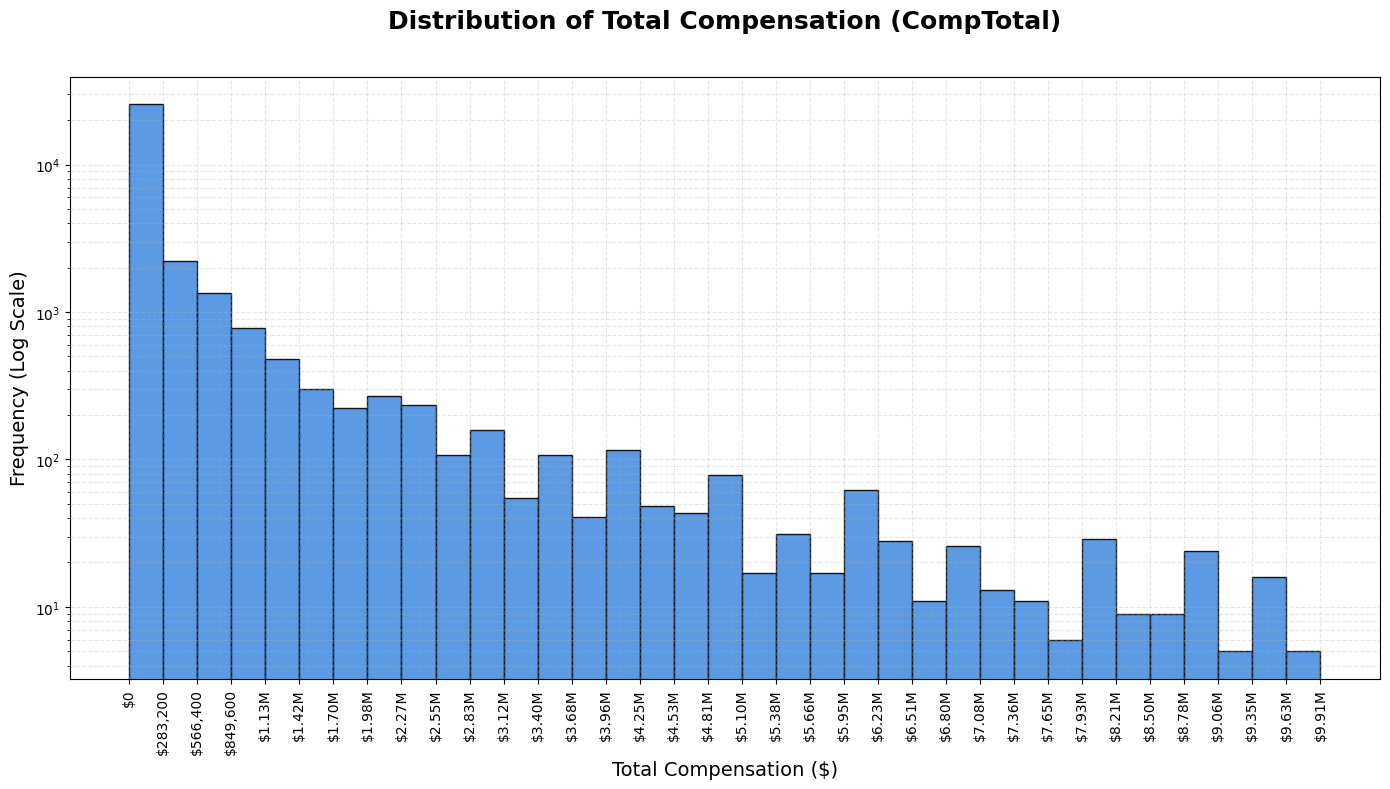

In [85]:


# Query CompTotal values (filtering extreme outliers > $10M)
QUERY = """
SELECT CompTotal FROM main 
WHERE CompTotal IS NOT NULL 
  AND CompTotal < 10000000
"""
df_comp = pd.read_sql_query(QUERY, conn)
print(f"Data loaded: {len(df_comp)} valid values")
print(f"Range: ${df_comp['CompTotal'].min():,.0f} to ${df_comp['CompTotal'].max():,.0f}")

# Create plot using subplots (avoiding plt.figure)
fig, ax = plt.subplots(figsize=(14, 8))

# Define explicit bin edges to align ticks exactly with the bar boundaries
num_bins = 35
min_val = df_comp['CompTotal'].min()
max_val = df_comp['CompTotal'].max()
bin_edges = np.linspace(min_val, max_val, num_bins + 1)

# Plot histogram using the defined bin edges
ax.hist(df_comp['CompTotal'], 
        bins=bin_edges, 
        edgecolor='black', 
        alpha=0.9,
        color='#4A90E2')

# Set y-axis to log scale to reveal the spread of smaller bars
ax.set_yscale('log')

# Add title and labels with appropriate spacing
ax.set_title('Distribution of Total Compensation (CompTotal)', fontsize=18, fontweight='bold', pad=35)
ax.set_xlabel('Total Compensation ($)', fontsize=14)
ax.set_ylabel('Frequency (Log Scale)', fontsize=14)

# Place x-ticks exactly at the bin edges and format for readability
ax.set_xticks(bin_edges)
# Formatting as Millions (e.g., $1.14M) to keep the labels clean and readable
tick_labels = [f"${x/1e6:.2f}M" if x >= 1e6 else f"${x:,.0f}" for x in bin_edges]
ax.set_xticklabels(tick_labels, rotation=90, fontsize=10)

# Add grid lines for easier readability across the log scale
ax.grid(True, alpha=0.3, linestyle='--', which='both')

# Ensure labels and ticks are fully visible and not truncated
plt.tight_layout()

plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


Data loaded: 51610 valid values
Range: 0 to 52 years


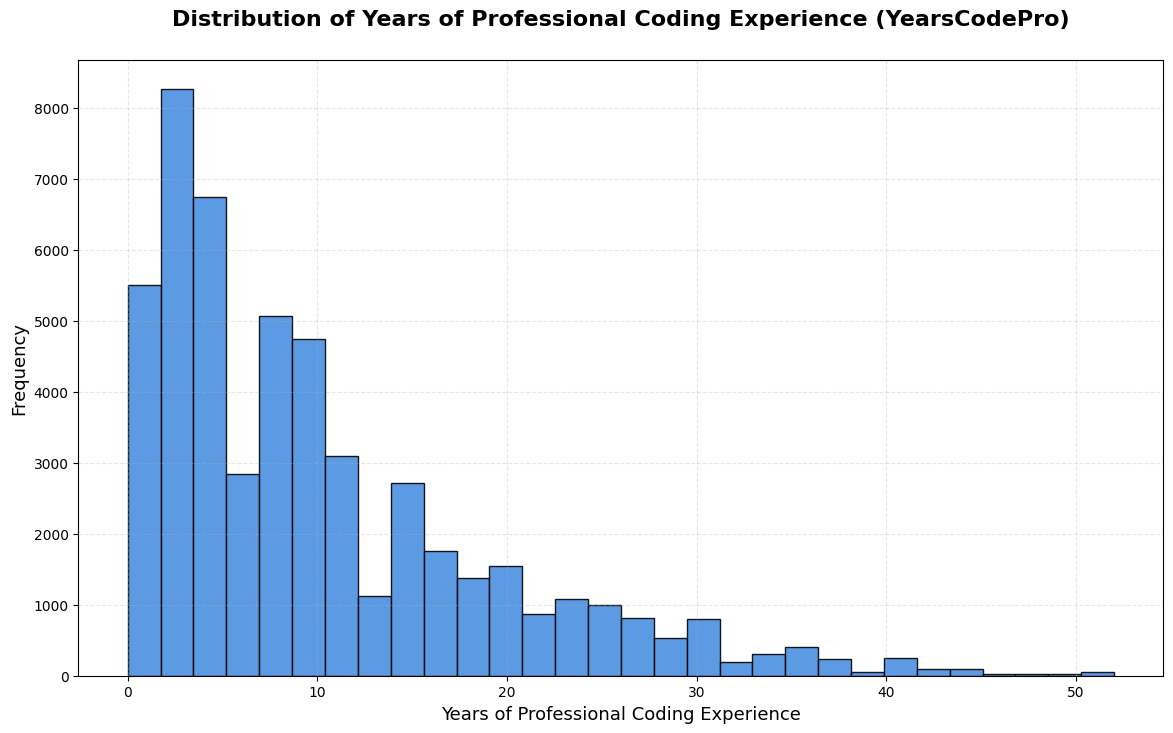

In [86]:
## Write your code here

# Query YearsCodePro with value conversions
QUERY = """
SELECT 
    CASE 
        WHEN YearsCodePro IS NULL THEN NULL
        WHEN YearsCodePro = 'Less than 1 year' THEN 0
        WHEN YearsCodePro = 'More than 50 years' THEN 52
        ELSE CAST(YearsCodePro AS INTEGER)
    END as years_code_pro
FROM main 
WHERE YearsCodePro IS NOT NULL
"""
df_years = pd.read_sql_query(QUERY, conn)
print(f"Data loaded: {len(df_years)} valid values")
print(f"Range: 0 to {max(df_years['years_code_pro'])} years")
# Create histogram with appropriate binning
plt.figure(figsize=(14, 8))
plt.hist(df_years['years_code_pro'], bins=30, edgecolor='black', alpha=0.9, color='#4A90E2')
plt.title('Distribution of Years of Professional Coding Experience (YearsCodePro)', fontsize=16, fontweight='bold', pad=25)
plt.xlabel('Years of Professional Coding Experience', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.grid(True, alpha=0.3, linestyle='--')
# Display plot (notebook will show automatically)
plt.show()

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


Data loaded: 8 age groups
   Prefer not to say         :   14 records, $60,000-$384,000
   Under 18 years old        :   90 records, $0-$1,939,403,990
   18-24 years old           : 4636 records, $0-$8,000,000,000,000,000,106,300,440,576
   25-34 years old           : 14657 records, $0-$1,000,000,000,000,000,162,545,277,246,339,097,227,904,071,986,031,452,381,501,504,981,983,615,182,576,228,378,136,120,296,965,701,983,510,464,738,707,067,395,631,197,433,897,752,887,331,883,780,669,440
   35-44 years old           : 9352 records, $0-$99,999,999,999,999,999,209,038,626,283,633,850,822,756,121,694,230,455,365,568,299,008
   45-54 years old           : 3516 records, $0-$10,000,000,000
   55-64 years old           : 1279 records, $0-$99,999,999,999,999,999,322,094,867,436,162,797,646,170,844,194,406,400
   65 years or older         :  196 records, $0-$2,400,000


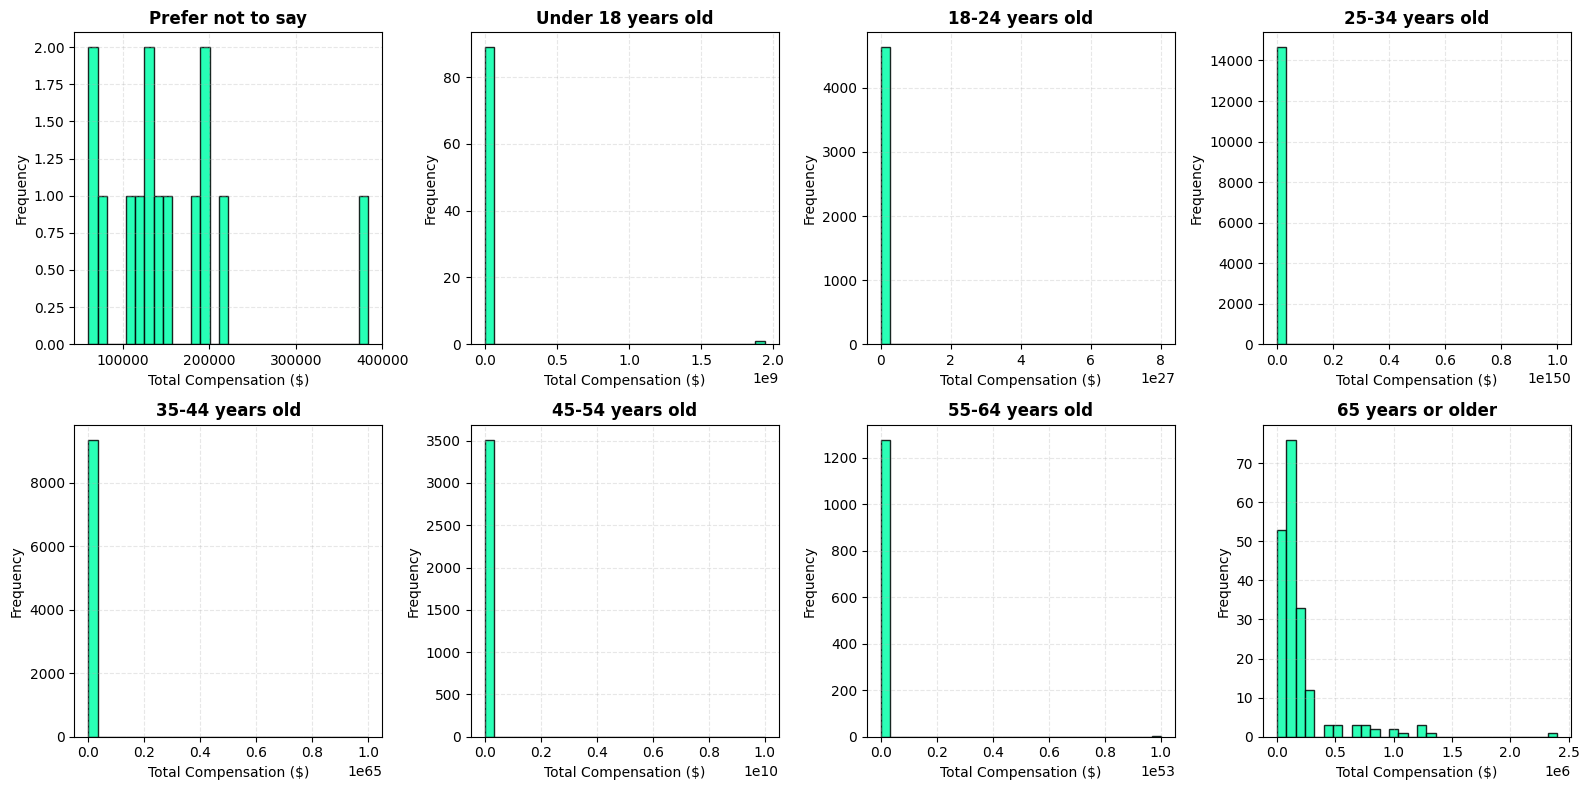

In [87]:
# Query CompTotal by age group with chronological sorting
QUERY = """
SELECT Age, COUNT(*) as count, 
       MIN(CompTotal) as min_comp, 
       MAX(CompTotal) as max_comp
FROM main 
WHERE Age IS NOT NULL AND CompTotal IS NOT NULL
GROUP BY Age
ORDER BY 
    CASE 
        WHEN Age LIKE 'Under%' THEN 0
        WHEN Age LIKE '18-24%' THEN 1
        WHEN Age LIKE '25-34%' THEN 2
        WHEN Age LIKE '35-44%' THEN 3
        WHEN Age LIKE '45-54%' THEN 4
        WHEN Age LIKE '55-64%' THEN 5
        WHEN Age LIKE '65%' THEN 6
    END
"""
# Execute query and create subplots (2x4 grid for 8 groups)
df_age = pd.read_sql_query(QUERY, conn)
print(f"Data loaded: {len(df_age)} age groups")
for _, row in df_age.iterrows():
    print(f"   {row['Age']:25} : {row['count']:4} records, ${row['min_comp']:,.0f}-${row['max_comp']:,.0f}")
# Create 2x4 grid of subplots (one per age group)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for idx, (_, row) in enumerate(df_age.iterrows()):
    # Query CompTotal for this age group
    age_query = f"""SELECT CompTotal FROM main WHERE Age = '{row['Age']}' AND CompTotal IS NOT NULL"""
    age_data = pd.read_sql_query(age_query, conn)
    
    axes[idx // 4, idx % 4].hist(age_data['CompTotal'], bins=30, edgecolor='black', alpha=0.85, color=f'#{(idx+1):02x}ffaa')
    axes[idx // 4, idx % 4].set_title(f'{row["Age"]}', fontsize=12, fontweight='bold')
    axes[idx // 4, idx % 4].set_xlabel('Total Compensation ($)', fontsize=10)
    axes[idx // 4, idx % 4].set_ylabel('Frequency', fontsize=10)
    axes[idx // 4, idx % 4].grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


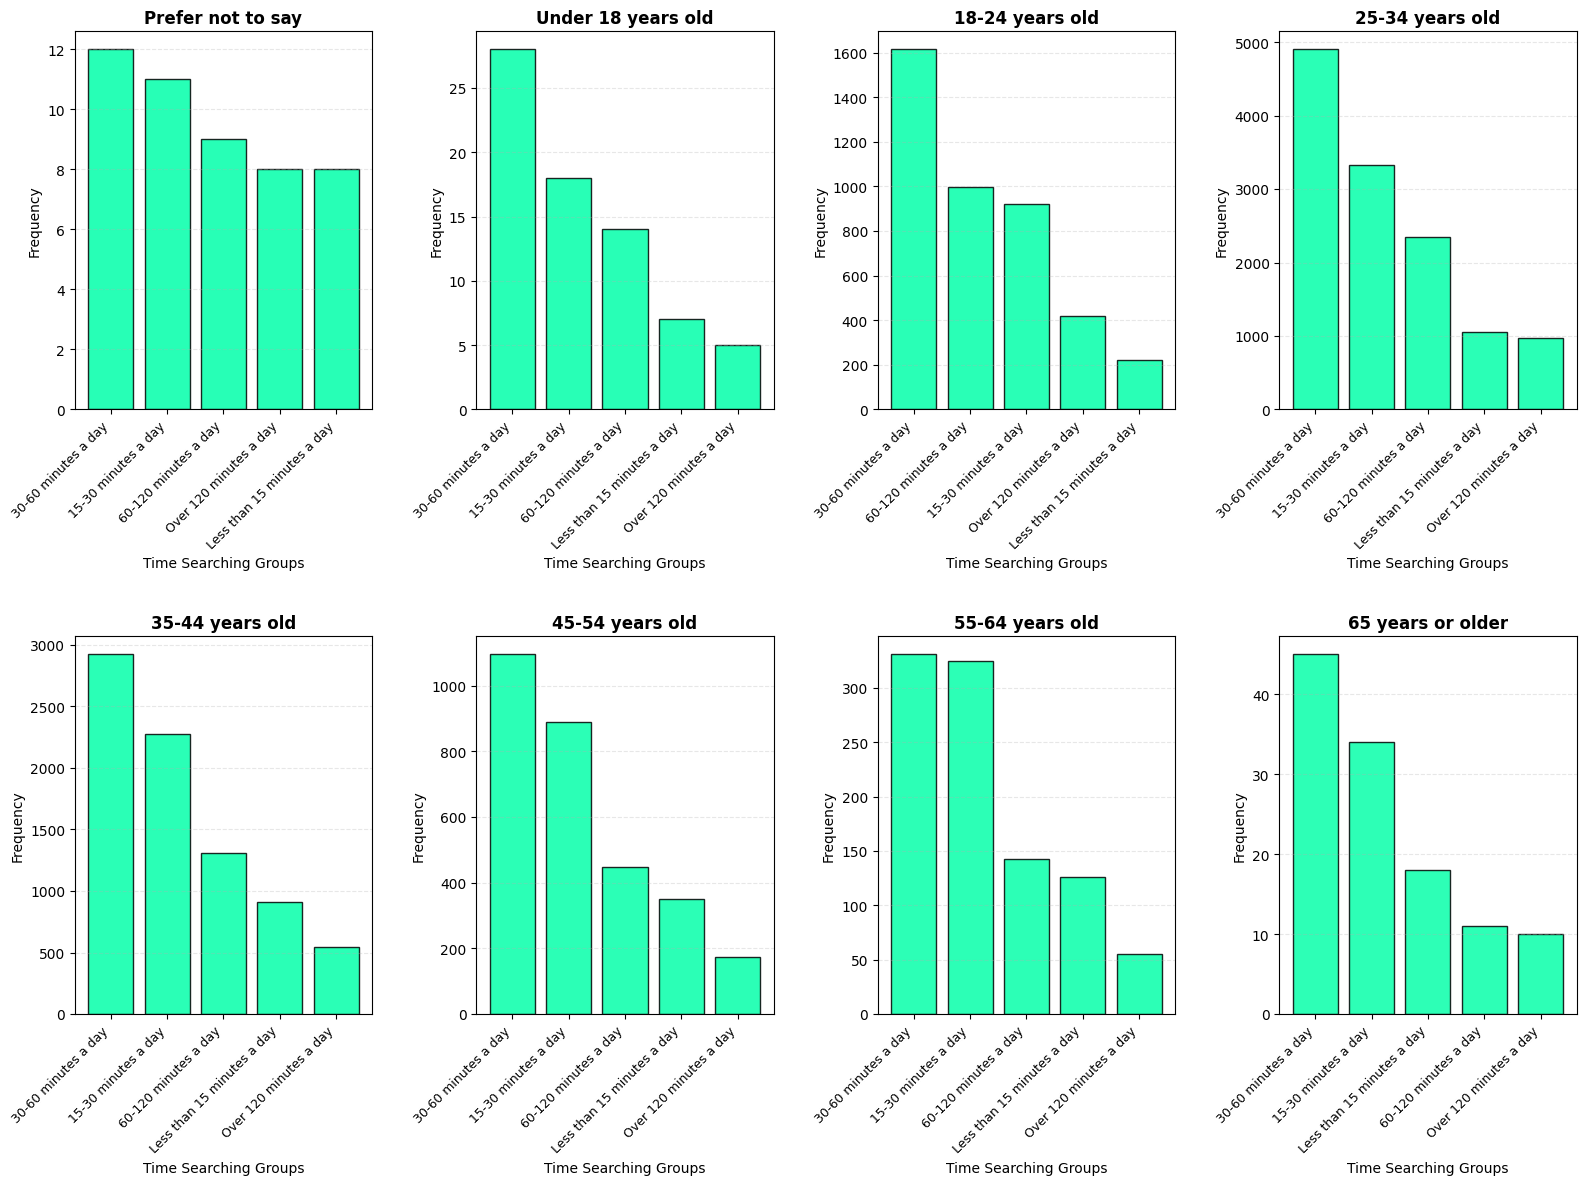

In [88]:



QUERY = """
SELECT Age, COUNT(*) as count, MIN(TimeSearching) as min_time, MAX(TimeSearching) as max_time
FROM main
WHERE Age IS NOT NULL AND TimeSearching IS NOT NULL
GROUP BY Age
ORDER BY CASE
    WHEN Age LIKE 'Under%' THEN 0
    WHEN Age LIKE '18-24%' THEN 1
    WHEN Age LIKE '25-34%' THEN 2
    WHEN Age LIKE '35-44%' THEN 3
    WHEN Age LIKE '45-54%' THEN 4
    WHEN Age LIKE '55-64%' THEN 5
    WHEN Age LIKE '65%' THEN 6
END
"""

df_age = pd.read_sql_query(QUERY, conn)

fig, axes = plt.subplots(2, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, (_, row) in enumerate(df_age.iterrows()):
    age_query = f"SELECT TimeSearching FROM main WHERE Age = '{row['Age']}' AND TimeSearching IS NOT NULL"
    age_data = pd.read_sql_query(age_query, conn)

    # 1. Aggregate categorical counts. 
    # value_counts() counts how many times each string category appears.
    cat_counts = age_data['TimeSearching'].value_counts()
    
    # Optional: If your categories need a specific order (e.g., "Short", "Medium", "Long"),
    # you can sort them here so all 8 graphs match.
    # cat_counts = cat_counts.reindex(['List', 'Your', 'Categories', 'In', 'Order'])

    ax = axes[idx]
    
    # 2. Use ax.bar instead of ax.hist
    # This automatically centers the tick under every bar!
    ax.bar(
        cat_counts.index, 
        cat_counts.values, 
        edgecolor='black', 
        alpha=0.85, 
        color=f'#{(idx+1):02x}ffaa'
    )
    
    # Plot styling
    ax.set_title(row['Age'], fontsize=12, fontweight='bold')
    ax.set_xlabel('Time Searching Groups', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--', axis='y') # Only grid on y-axis for cleaner categorical look

    # Rotate the clean, non-flooded categorical text labels
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')
        label.set_fontsize(9)

# Hide any empty subplots
for j in range(len(df_age), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
fig.subplots_adjust(hspace=0.6, wspace=0.35, bottom=0.15)
plt.show()

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


Top 10 desired databases:
   PostgreSQL                : 3,738
   PostgreSQL;SQLite         : 1,533
   SQLite                    : 1,476
   Microsoft SQL Server      : 1,431
   MySQL                     : 1,139
   MongoDB                   : 917
   PostgreSQL;Redis          : 855
   MongoDB;PostgreSQL        : 600
   MySQL;PostgreSQL          : 504
   PostgreSQL;Redis;SQLite   : 411


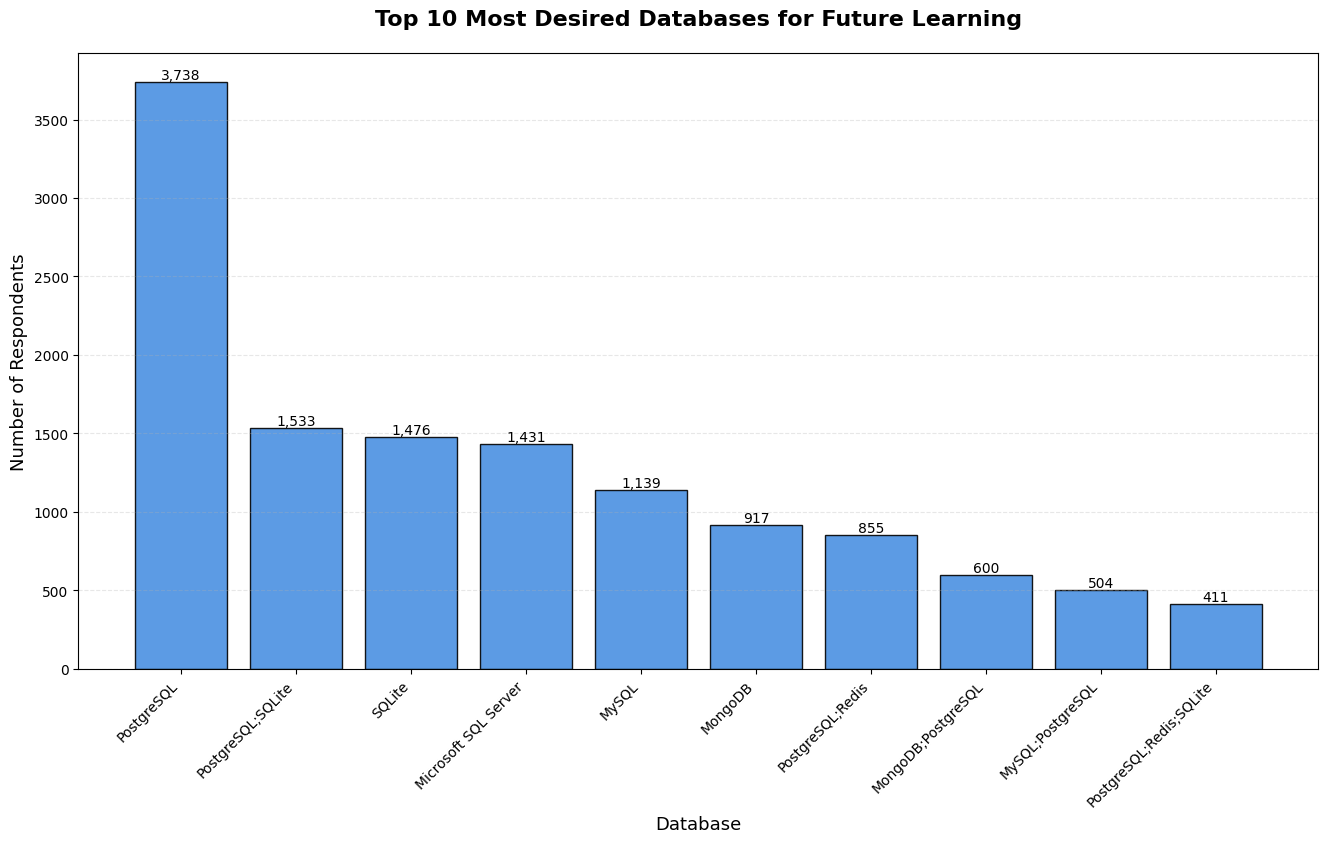

In [89]:
## Write your code here
# Query top 10 desired databases with counts
QUERY = """
SELECT DatabaseWantToWorkWith, COUNT(*) as count
FROM main
WHERE DatabaseWantToWorkWith IS NOT NULL AND DatabaseWantToWorkWith != ''
GROUP BY DatabaseWantToWorkWith
ORDER BY count DESC
LIMIT 10
"""
df_db = pd.read_sql_query(QUERY, conn)
print(f"Top {len(df_db)} desired databases:")
for _, row in df_db.iterrows():
    print(f"   {row['DatabaseWantToWorkWith']:25} : {row['count']:,}")
# Create bar chart (histogram-style visualization for categorical data)
plt.figure(figsize=(16, 8))
bars = plt.bar(df_db['DatabaseWantToWorkWith'], df_db['count'], 
                color='#4A90E2', edgecolor='black', alpha=0.9)
# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:,}', ha='center', va='bottom', fontsize=10)
plt.title('Top 10 Most Desired Databases for Future Learning', 
           fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Database', fontsize=13)
plt.ylabel('Number of Respondents', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y', linestyle='--')
# Display in notebook
plt.show()

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


Remote work preferences (3 categories):
   Hybrid (some remote, some in-person) : 23,015
   Remote               : 20,831
   In-person            : 10,960


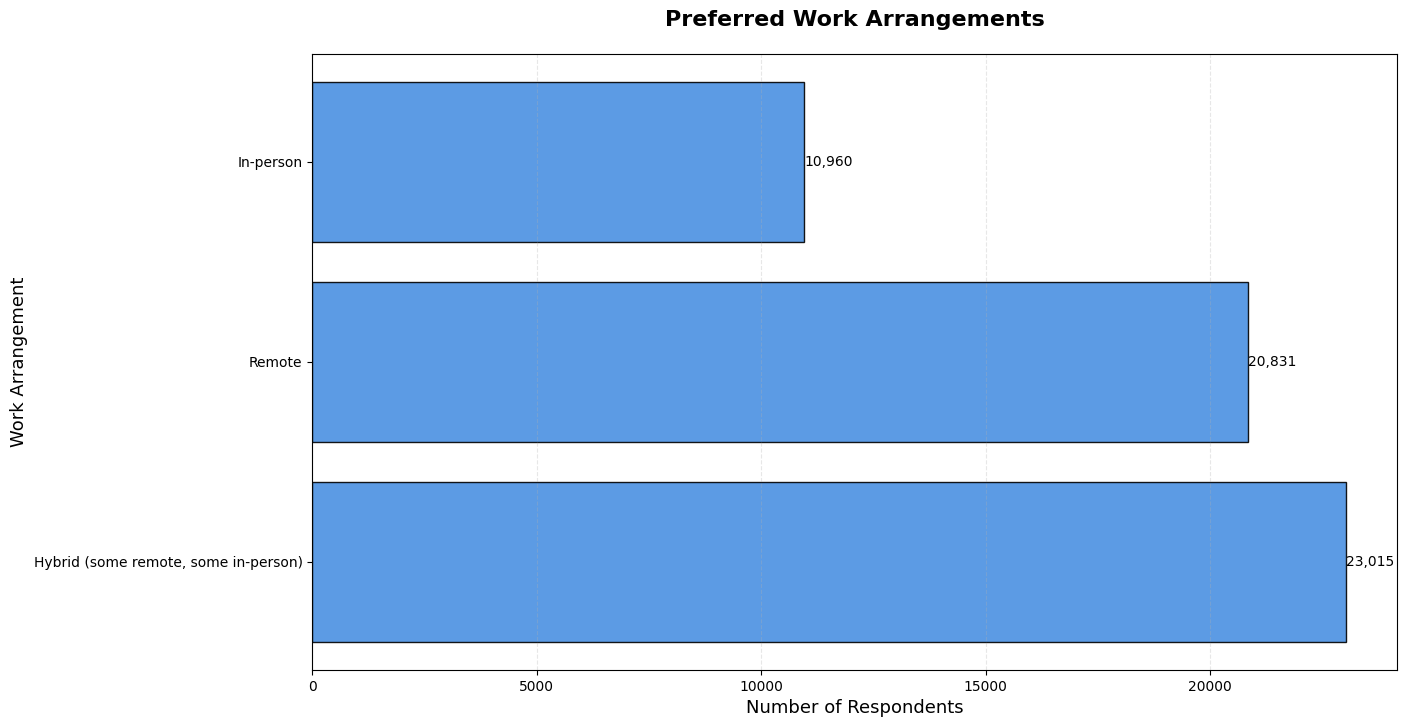

In [90]:
## Write your code here

# Query all remote work preferences with counts
QUERY = """
SELECT RemoteWork, COUNT(*) as count
FROM main
WHERE RemoteWork IS NOT NULL AND RemoteWork != ''
GROUP BY RemoteWork
ORDER BY count DESC
"""
df_remote = pd.read_sql_query(QUERY, conn)
print(f"Remote work preferences ({len(df_remote)} categories):")
for _, row in df_remote.iterrows():
    print(f"   {row['RemoteWork']:20} : {row['count']:,}")
# Create horizontal bar chart (better for categorical data with longer labels)
plt.figure(figsize=(14, 8))
bars = plt.barh(df_remote['RemoteWork'], df_remote['count'], 
                 color='#4A90E2', edgecolor='black', alpha=0.9)
# Add value labels on right side of bars
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2.,
             f'{width:,}', ha='left', va='center', fontsize=10)
plt.title('Preferred Work Arrangements', 
           fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Respondents', fontsize=13)
plt.ylabel('Work Arrangement', fontsize=13)
plt.grid(True, alpha=0.3, axis='x', linestyle='--')
# Display in notebook
plt.show()

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


Data loaded: 4716 valid values
Range: $0 to $9,700,000


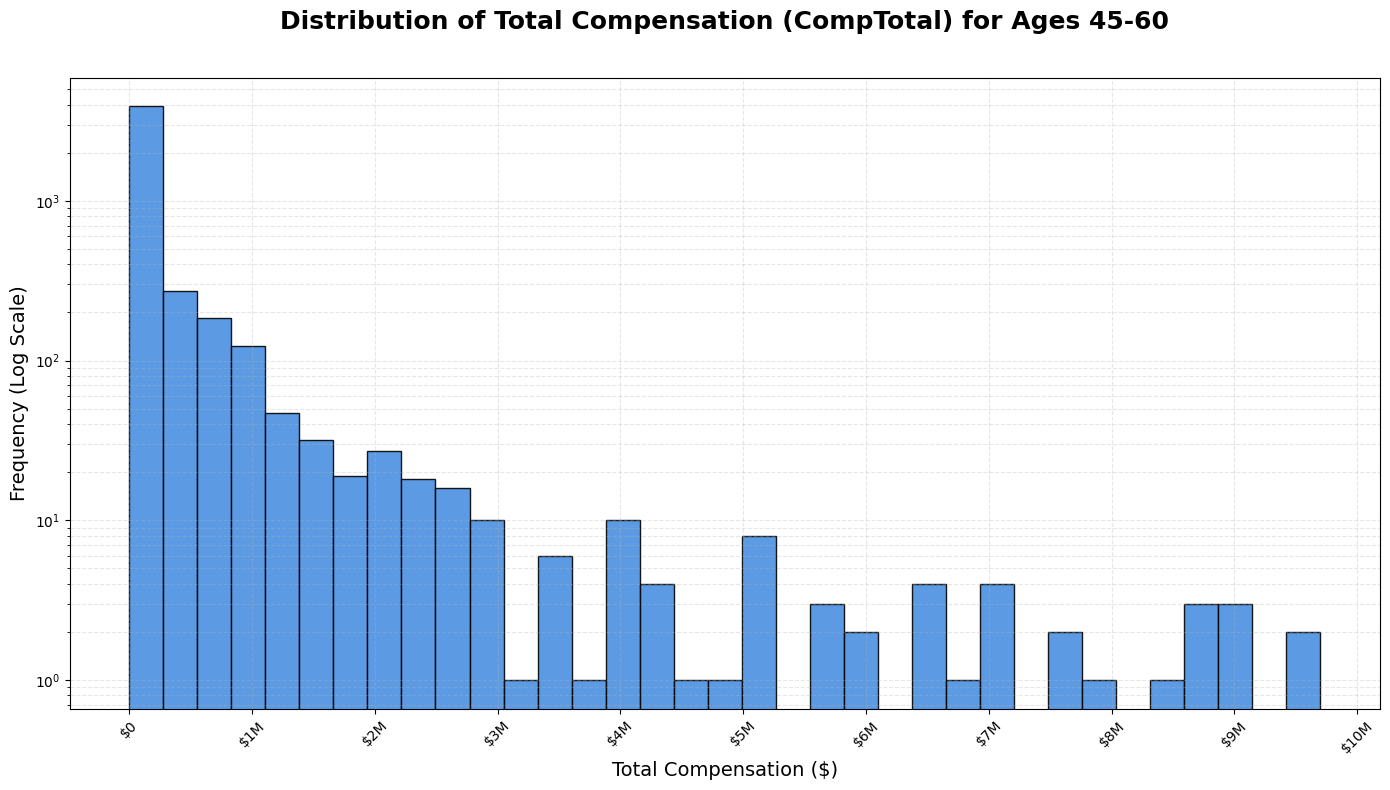

In [91]:
import matplotlib.ticker as ticker

# Query CompTotal for ages 45-60
QUERY = """
SELECT CompTotal 
FROM main 
WHERE Age IN ('45-54 years old', '55-64 years old') 
  AND CompTotal IS NOT NULL 
  AND CompTotal < 10000000
"""
df_age_45_60 = pd.read_sql_query(QUERY, conn)
print(f"Data loaded: {len(df_age_45_60)} valid values")
print(f"Range: ${df_age_45_60['CompTotal'].min():,.0f} to ${df_age_45_60['CompTotal'].max():,.0f}")

# Create histogram with adjusted parameters for better visibility
fig, ax = plt.subplots(figsize=(14, 8))

ax.hist(df_age_45_60['CompTotal'], 
        bins=35,           # Reduced from 60 to show more spread
        edgecolor='black', 
        alpha=0.9,
        color='#4A90E2',
        log=True)          # Log scale handles the 0 peak and exposes smaller peaks

# Adjust x-axis ticks for better visibility (intervals of 1,000,000 formatted as $M)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1000000))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x*1e-6:.0f}M' if x != 0 else '$0'))
plt.xticks(rotation=45)

# Add title and labels with better spacing
ax.set_title('Distribution of Total Compensation (CompTotal) for Ages 45-60', fontsize=18, fontweight='bold', pad=35)
ax.set_xlabel('Total Compensation ($)', fontsize=14)
ax.set_ylabel('Frequency (Log Scale)', fontsize=14)

# Add grid for readability (both major and minor grids work well with log scale)
ax.grid(True, which="both", alpha=0.3, linestyle='--')

# Optimize layout and save the visualization
plt.tight_layout()
plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


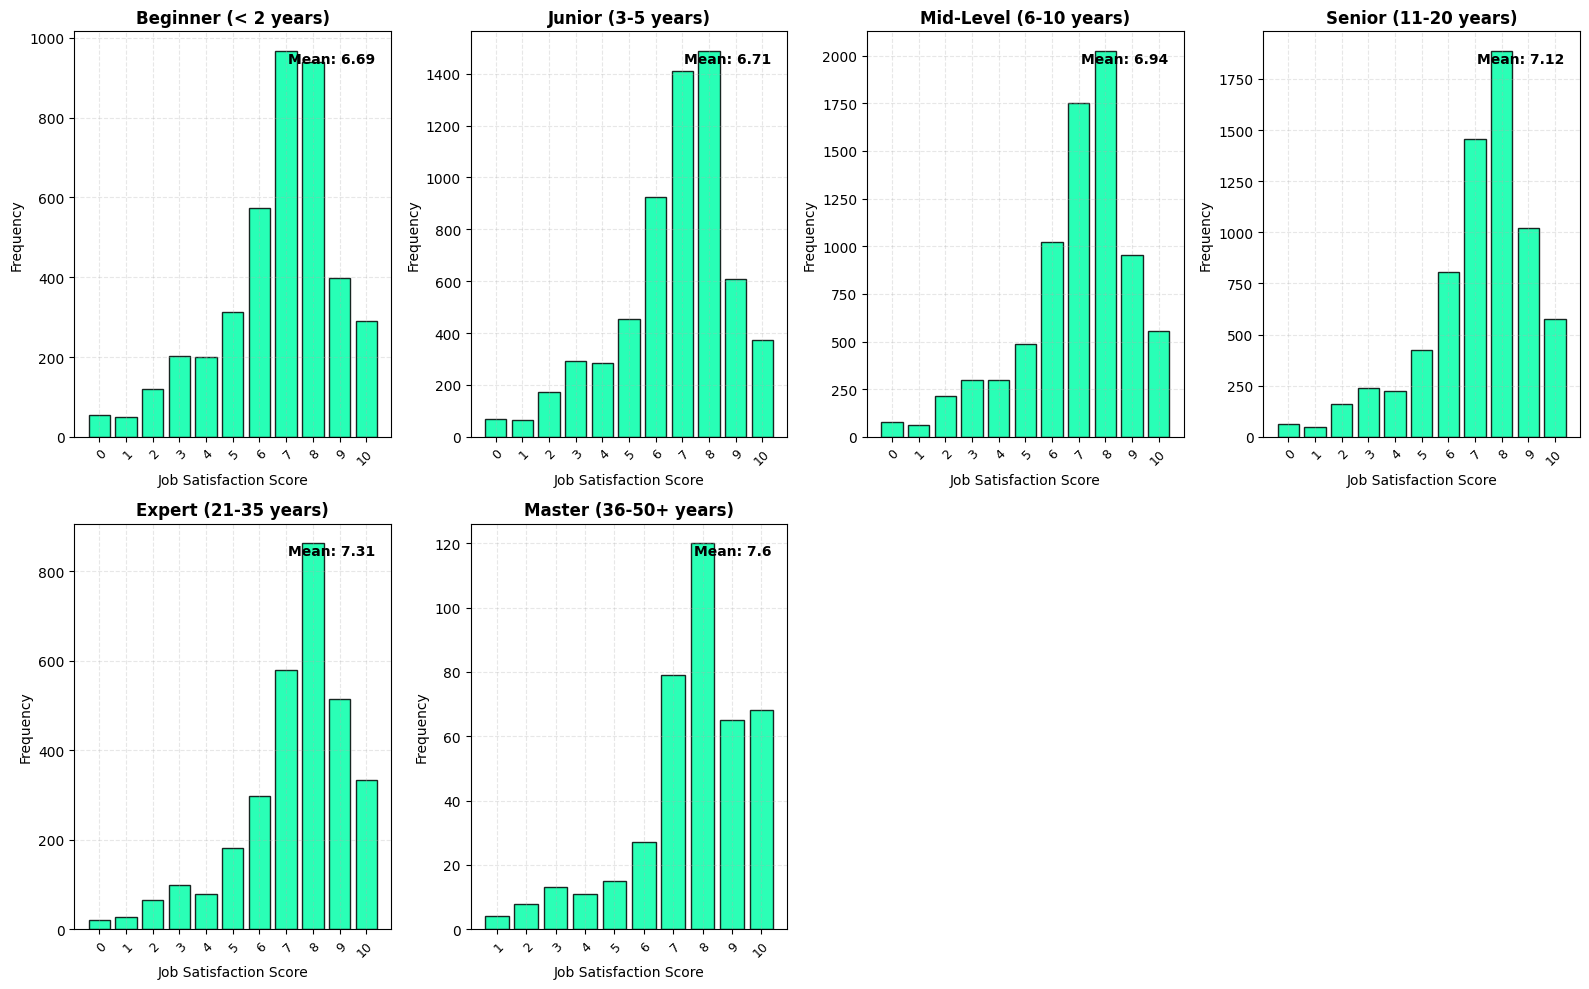

In [92]:


# 1. Define experience buckets with ranges (ordered by experience level)
buckets = {
    'Beginner': ('< 2 years', ['Less than 1 year', '1', '2']),
    'Junior': ('3-5 years', ['3', '4', '5']),
    'Mid-Level': ('6-10 years', ['6', '7', '8', '9', '10']),
    'Senior': ('11-20 years', ['11', '12', '13', '14', '15', '16', '17', '18', '19', '20']),
    'Expert': ('21-35 years', ['21', '22', '23', '24', '25', '26', '27', '28', '29', '30', 
                               '31', '32', '33', '34', '35']),
    'Master': ('36-50+ years', ['36', '37', '38', '39', '40', '41', '42', '43', '44', '45', 
                                '46', '47', '48', '49', '50', 'More than 50 years'])
}

# 2. Query overall JobSat to check counts
QUERY = """
SELECT 
    CASE 
        WHEN YearsCodePro IN ('Less than 1 year', '1', '2') THEN 'Beginner'
        WHEN YearsCodePro IN ('3', '4', '5') THEN 'Junior'
        WHEN YearsCodePro IN ('6', '7', '8', '9', '10') THEN 'Mid-Level'
        WHEN YearsCodePro IN ('11', '12', '13', '14', '15', '16', '17', '18', '19', '20') THEN 'Senior'
        WHEN YearsCodePro IN ('21', '22', '23', '24', '25', '26', '27', '28', '29', '30', 
                              '31', '32', '33', '34', '35') THEN 'Expert'
        WHEN YearsCodePro IN ('36', '37', '38', '39', '40', '41', '42', '43', '44', '45', 
                              '46', '47', '48', '49', '50', 'More than 50 years') THEN 'Master'
        ELSE NULL
    END as experience_bucket,
    JobSat
FROM main 
WHERE YearsCodePro IS NOT NULL AND JobSat IS NOT NULL
"""
df_job = pd.read_sql_query(QUERY, conn)

# 3. Create subplots (2x4 grid for 8 buckets)
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

# Get sorted bucket order (least to most experienced)
sorted_buckets = ['Beginner', 'Junior', 'Mid-Level', 'Senior', 'Expert', 'Master']

for idx, bucket in enumerate(sorted_buckets):
    if bucket not in df_job['experience_bucket'].unique():
        continue
        
    range_label, exp_values = buckets[bucket]
    
    # Query JobSat for this specific experience bucket
    exp_query = f"""
    SELECT JobSat 
    FROM main 
    WHERE YearsCodePro IN ({', '.join(f"'{v}'" for v in exp_values)}) AND JobSat IS NOT NULL
    """
    exp_data = pd.read_sql_query(exp_query, conn)
    mean_sat = round(exp_data['JobSat'].mean(), 2)
    
    ax = axes[idx]
    
    # --- CRITICAL FIX PART 1: Center bins around integer scores ---
    # Find the range of actual scores
    min_score = int(exp_data['JobSat'].min())
    max_score = int(exp_data['JobSat'].max())
    
    # Create bin edges that sit half a unit left and right of integers (e.g., 0.5 to 1.5 for score 1)
    bin_edges = np.arange(min_score - 0.5, max_score + 1.5, 1)
    
    # Plotting the histogram
    ax.hist(exp_data['JobSat'], bins=bin_edges, edgecolor='black', alpha=0.85, 
            color=f'#{(idx+1):02x}ffaa', rwidth=0.8) # rwidth adds a slight gap between bars for look
    
    # --- CRITICAL FIX PART 2: Set ticks to the exact integer centers ---
    # Instead of the sides (edges), we explicitly place ticks on the integer values
    unique_scores = np.arange(min_score, max_score + 1)
    ax.set_xticks(unique_scores)
    
    # Title and labels
    ax.set_title(f'{bucket} ({range_label})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Job Satisfaction Score', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # --- CRITICAL FIX PART 3: Alignment Correction ---
    # With 'center' data alignment, we rotate and anchor seamlessly
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor', fontsize=9)
    
    # Add mean satisfaction label in top-right corner
    ax.text(0.95, 0.95, f'Mean: {mean_sat}', 
            transform=ax.transAxes, ha='right', va='top', fontsize=10, fontweight='bold')

# Hide any unused subplots
for j in range(len(sorted_buckets), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [93]:
#conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
